In [3]:
from google.colab import files
import pandas as pd
import zipfile
import io
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt')
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [4]:
#download data from: https://www.osha.gov/severe-injury-reports

uploaded=files.upload()
file=list(uploaded.keys())[0]

with zipfile.ZipFile(io.BytesIO(uploaded[file]), 'r') as z:
  print("Files in zip:", z.namelist())
  csv_file = [f for f in z.namelist() if f.endswith('.csv')][0]
  with z.open(csv_file) as csvfile:
        df = pd.read_csv(csvfile)

print(df.head())

Saving January2015toJuly2025.zip to January2015toJuly2025.zip
Files in zip: ['January2015toJuly2025.csv']
           ID     UPA EventDate  \
0  2015010015  931176  1/1/2015   
1  2015010016  930267  1/1/2015   
2  2015010018  929823  1/1/2015   
3  2015010019  929711  1/1/2015   
4  2015010020  929642  1/1/2015   

                                         Employer               Address1  \
0  FCI Otisville Federal Correctional Institution         Two Mile Drive   
1                      Kalahari Manufacturing LLC     171 Progress Drive   
2                 Schneider National Bulk Carrier    420 CORAOPOLIS ROAD   
3                       PEPSI BOTTLING GROUP INC.      4541 HOUSTON AVE.   
4                 North American Pipe Corporation  210 South Arch Street   

  Address2         City         State      Zip  Latitude  ...  \
0      NaN    OTISVILLE      NEW YORK  10963.0     41.46  ...   
1      NaN  LAKE DELTON     WISCONSIN  53940.0     43.59  ...   
2      NaN   CORAOPOLIS  PENNSY

/tmp/ipykernel_5487/2843285358.py:10: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csvfile)


In [5]:
# cleaning

# Check basic info about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values count:")
print(df.isnull().sum())

missing_pct=(df.isnull().sum() / len(df)) *100
print("Missing values percentage:")
print(missing_pct[missing_pct>0].sort_values(ascending=False))

# dropped columnms
cols_to_drop = ['Address2', 'Secondary Source', 'Secondary Source Title', 'Inspection']
df_clean = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns with high missing values. New shape: {df_clean.shape}")

# fill in what we can
numeric_cols = ['Zip', 'Latitude', 'Longitude', 'Secondary Source']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

text_cols = ['Address1', 'City']
for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Unknown')

Dataset shape: (102922, 28)

Column names:
['ID', 'UPA', 'EventDate', 'Employer', 'Address1', 'Address2', 'City', 'State', 'Zip', 'Latitude', 'Longitude', 'Primary NAICS', 'Hospitalized', 'Amputation', 'Loss of Eye', 'Inspection', 'Final Narrative', 'Nature', 'NatureTitle', 'Part of Body', 'Part of Body Title', 'Event', 'EventTitle', 'Source', 'SourceTitle', 'Secondary Source', 'Secondary Source Title', 'FederalState']

Data types:
ID                          int64
UPA                         int64
EventDate                  object
Employer                   object
Address1                   object
Address2                   object
City                       object
State                      object
Zip                       float64
Latitude                  float64
Longitude                 float64
Primary NAICS              object
Hospitalized              float64
Amputation                float64
Loss of Eye               float64
Inspection                float64
Final Narrative     

In [6]:
# convert data types
df_clean['ID']=df_clean['ID'].astype(str)
df_clean['UPA']=df_clean['UPA'].astype(str)
df_clean['EventDate']=pd.to_datetime(df_clean['EventDate'], errors='coerce')

binary_cols=['Hospitalized', 'Amputation', 'Loss of Eye', 'FederalState']
for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0).astype(int)

df_clean['Primary NAICS']=df_clean['Primary NAICS'].fillna('Unknown').astype(str)

# new text column
text_columns=['Final Narrative', 'EventTitle', 'NatureTitle', 'Part of Body Title', 'SourceTitle']

for col in text_columns:
  if col in df_clean.columns:
    df_clean[col] = df_clean[col].fillna('')

df_clean['combined_text']=(
    df_clean['Final Narrative'] + ' ' +
    df_clean['EventTitle'] + ' ' +
    df_clean['NatureTitle'] + ' ' +
    df_clean['Part of Body Title'] + ' ' +
    df_clean['SourceTitle']
)

print(f"Sample combined text:\n{df_clean['combined_text'].iloc[0][:500]}")

Sample combined text:
Three correctional facility guards were escorting a restrained federal prison inmate when he became disruptive, requiring the use of force. 
Two guards and the inmate fell onto the Lieutenant's right leg, fracturing his fibula. He was transported to the hospital and released the following day. Injured by physical contact with person while restraining, subduing-unintentional Fractures Lower leg(s) Co-worker


In [7]:
# select features for clustering

cluster_features=[
    'Primary NAICS',
    'Hospitalized',
    'Amputation',
    'Loss of Eye',
    'FederalState',
    'NatureTitle',
    'Part of Body Title',
    'combined_text',
    'EventTitle',
    'SourceTitle'
]

df_cluster=df_clean[cluster_features].copy()
df_cluster.head()

,Primary NAICS,Hospitalized,Amputation,Loss of Eye,FederalState,NatureTitle,Part of Body Title,combined_text,EventTitle,SourceTitle
0,922140,1,0,0,1,Fractures,Lower leg(s),Three correctional facility guards were escort...,Injured by physical contact with person while ...,Co-worker
1,339999,1,0,0,1,Second degree heat (thermal) burns,"Leg(s), n.e.c.",Employee in the Machine Shop received second d...,"Ignition of vapors, gases, or liquids","Welding, cutting, and blow torches"
2,484121,1,0,0,1,"Traumatic injuries and disorders, unspecified",Nonclassifiable,A truck driver fell approximately 4 feet while...,Other fall to lower level less than 6 feet,"Semi, tractor-trailer, tanker truck"
3,424490,1,0,0,1,"Soreness, pain, hurt-nonspecified injury","Leg(s), unspecified",An employee's leg was pinned between a truck a...,Caught in or compressed by equipment or object...,Pallet jack-powered
4,326122,1,0,0,1,Fractures,"Finger(s), fingernail(s), n.e.c.",An employee working on the Line 6 Auto-Beller ...,Caught in running equipment or machinery durin...,"Metal, woodworking, and special material machi..."


In [6]:
import nltk
nltk.download('stopwords', quiet=False)
nltk.download('punkt', quiet=False)
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [7]:
# text preprocessing function

import nltk
nltk.download('punkt_tab', quiet=False)


# stopwords
stop_words=set(stopwords.words('english'))

custom_stops = {'employee', 'worker', 'incident', 'reported', 'injury', 'injuries',
                'work', 'workplace', 'company', 'employer', 'would', 'could',
                'also', 'one', 'two', 'three', 'got', 'get', 'went', 'went'}
stop_words.update(custom_stops)

def preprocess_text(text):
    """
    Clean and preprocess text for NLP analysis
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]

    return ' '.join(tokens)

df_cluster['clean_text']=df_cluster['combined_text'].apply(preprocess_text)

print(f"\nOriginal text sample:\n{df_cluster['combined_text'].iloc[0][:300]}...")
print(f"\nCleaned text sample:\n{df_cluster['clean_text'].iloc[0][:300]}...")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Original text sample:
Three correctional facility guards were escorting a restrained federal prison inmate when he became disruptive, requiring the use of force. 
Two guards and the inmate fell onto the Lieutenant's right leg, fracturing his fibula. He was transported to the hospital and released the following day. Inju...

Cleaned text sample:
correctional facility guards escorting restrained federal prison inmate became disruptive requiring use force guards inmate fell onto lieutenants right leg fracturing fibula transported hospital released following day injured physical contact person restraining subduingunintentional fractures lower ...


In [8]:
# frequency vectors
tfidf_vectorizer=TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1,2)
)

tfidf_matrix=tfidf_vectorizer.fit_transform(df_cluster['clean_text'])

print(f"{tfidf_matrix.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")
tfidf_vectorizer.get_feature_names_out()[:20]

(102922, 5000)
Number of features: 5000


array(['abdomen', 'abdomen except', 'abdomen unspecified', 'abdominal',
       'abraders', 'abrasion', 'abrasions', 'abrasions bruises',
       'abrasions scratches', 'access', 'accessories', 'accessories nec',
       'accident', 'acid', 'across', 'activated', 'activities',
       'actuated', 'actuator', 'adding'], dtype=object)

In [9]:
from sklearn.decomposition import LatentDirichletAllocation

In [10]:
# LDA

count_vectorizer=CountVectorizer(
    max_df=0.8,
    min_df=5,
    max_features=3000,
    stop_words='english'
)

count_matrix=count_vectorizer.fit_transform(df_cluster['clean_text'])

print(f"Count Matrix shape: {count_matrix.shape}")
print(f"vocabulary size: {len(count_vectorizer.get_feature_names_out())}")

n_topics = 10

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    max_iter=100,
    learning_method='online'
)

lda.fit(count_matrix)

feature_names=count_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[:-11:-1]  # top 10
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

Count Matrix shape: (102922, 3000)
vocabulary size: 3000
Topic 1: internal, injured, object, hip, lacerations, cuts, nec, tripped, location, disorders
Topic 2: surfaces, walkways, floors, unspecified, femur, thighs, bar, body, hospitalized, systems
Topic 3: head, struck, unspecified, brain, wounds, intracranial, nails, hospitalized, nonclassifiable, testing
Topic 4: vehicle, forklift, truck, unspecified, struck, pallet, nonroadway, powered, platform, foot
Topic 5: pain, soreness, hurtnonspecified, door, unspecified, avulsions, enucleations, parking, including, lot
Topic 6: fall, level, fell, unspecified, fractures, lower, feet, floor, ground, ladder
Topic 7: heat, burns, unspecified, body, exposure, nec, hot, hospitalized, systems, degree
Topic 8: employees, objects, pinched, equipment, unspecified, shifting, compressed, pipe, left, metal
Topic 9: fractures, struck, nec, multiple, fell, falling, broken, object, parts, leg
Topic 10: caught, machinery, equipment, amputations, fingers, fi

In [11]:
# explore text data distribution

df_cluster['text_length'] = df_cluster['clean_text'].apply(lambda x: len(x.split()))
print(df_cluster['text_length'].describe())

empty_texts=(df_cluster['clean_text']== '').sum()
print(f"\nNumber of empty texts: {empty_texts} ({empty_texts/len(df_cluster)*100:.2f}%)")

if empty_texts>0:
  df_cluster=df_cluster[df_cluster['clean_text']!='']
  print(f"Removed {empty_texts} empty texts. New shape: {df_cluster.shape}")

count    102922.000000
mean         28.874614
std           9.015782
min           6.000000
25%          23.000000
50%          27.000000
75%          33.000000
max         199.000000
Name: text_length, dtype: float64

Number of empty texts: 0 (0.00%)


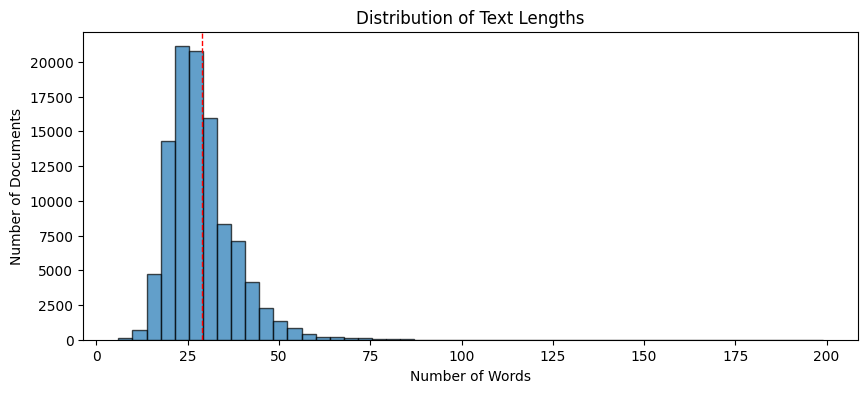

Top 20 most common words:
 unspecified: 83970
 nec: 45119
 fractures: 41465
 equipment: 38931
 fall: 36281
 caught: 35990
 fell: 34420
 struck: 34273
 left: 31860
 right: 30006
 level: 29964
 machinery: 28874
 amputations: 27991
 employees: 27868
 lower: 24725
 fingers: 23625
 finger: 23227
 feet: 22191
 object: 20587
 vehicle: 19882


In [12]:
import matplotlib.pyplot as plt

# text data visualization

plt.figure(figsize=(10,4))
plt.hist(df_cluster['text_length'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Words')
plt.ylabel('Number of Documents')
plt.title('Distribution of Text Lengths')
plt.axvline(df_cluster['text_length'].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean: {df_cluster["text_length"].mean():.1f}')
plt.legend
plt.show()

from collections import Counter

all_words= ' '.join(df_cluster['clean_text']).split()
word_counts=Counter(all_words)
print("Top 20 most common words:")
for word, count in word_counts.most_common(20):
  print(f" {word}: {count}")

In [13]:
# k means
k=8

sample_size=min(50000, tfidf_matrix.shape[0])
indices=np.random.choice(tfidf_matrix.shape[0], sample_size, replace=False)
tfidf_sample=tfidf_matrix[indices]

print(f"Sampled {sample_size} documents for training")
kmeans_pp=KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
kmeans_pp.fit(tfidf_sample)

labels_pp=kmeans_pp.predict(tfidf_matrix)
centers_pp=kmeans_pp.cluster_centers_

print(f"Cluster centers shape: {centers_pp.shape}")
print(f"Cluster distribution:")
unique, counts=np.unique(labels_pp, return_counts=True)
for cluster, count in zip(unique, counts):
  print(f" Cluster {cluster}: {count} documents ({count/len(labels_pp)*100:.1f}%)")

Sampled 50000 documents for training
Cluster centers shape: (8, 5000)
Cluster distribution:
 Cluster 0: 7864 documents (7.6%)
 Cluster 1: 17420 documents (16.9%)
 Cluster 2: 16076 documents (15.6%)
 Cluster 3: 11920 documents (11.6%)
 Cluster 4: 35376 documents (34.4%)
 Cluster 5: 4379 documents (4.3%)
 Cluster 6: 7309 documents (7.1%)
 Cluster 7: 2578 documents (2.5%)


In [14]:
#visualize k means
feature_names=tfidf_vectorizer.get_feature_names_out()

def get_top_words(cluster_center, feature_names, n_words=10):
  top_indices=cluster_center.argsort()[-n_words:][::-1]
  return [feature_names[i] for i in top_indices]

print("\n" + "="*60)
print(f"Cluster Palette (Top words defining each of the {k} injury patterns)")
print("="*60)

for i in range(k):
  top_words=get_top_words(centers_pp[i], feature_names, n_words=10)
  print(f"Cluster {i+1} (Size: {counts[i]}): {', '.join(top_words)}")


Cluster Palette (Top words defining each of the 8 injury patterns)
Cluster 1 (Size: 7864): compressed, objects, pinched, objects equipment, compressed pinched, pinched shifting, shifting objects, shifting, equipment, finger
Cluster 2 (Size: 17420): feet, lower, lower level, fall lower, fall, level, fell, ladder, unspecified, fractures
Cluster 3 (Size: 16076): machinery, caught, running, caught running, equipment machinery, running equipment, equipment, machine, amputations, fingers
Cluster 4 (Size: 11920): fall level, floor, level due, due, level, fall, fell, floor nec, fractures, tripping
Cluster 5 (Size: 35376): struck, object, vehicle, unspecified, injured, nec, employees, fractures, left, falling
Cluster 6 (Size: 4379): forklift, picker, order picker, order, forklift order, picker platform, platform, truckpowered, platform truckpowered, nonroadway
Cluster 7 (Size: 7309): burns, hot, degree, thermal, thermal burns, electrical, unspecified, heat thermal, burns unspecified, heat
Clus

k=4: inertia=18747
k=6: inertia=18403
k=8: inertia=18144
k=10: inertia=18054
k=12: inertia=17745
k=15: inertia=17443
k=20: inertia=17122


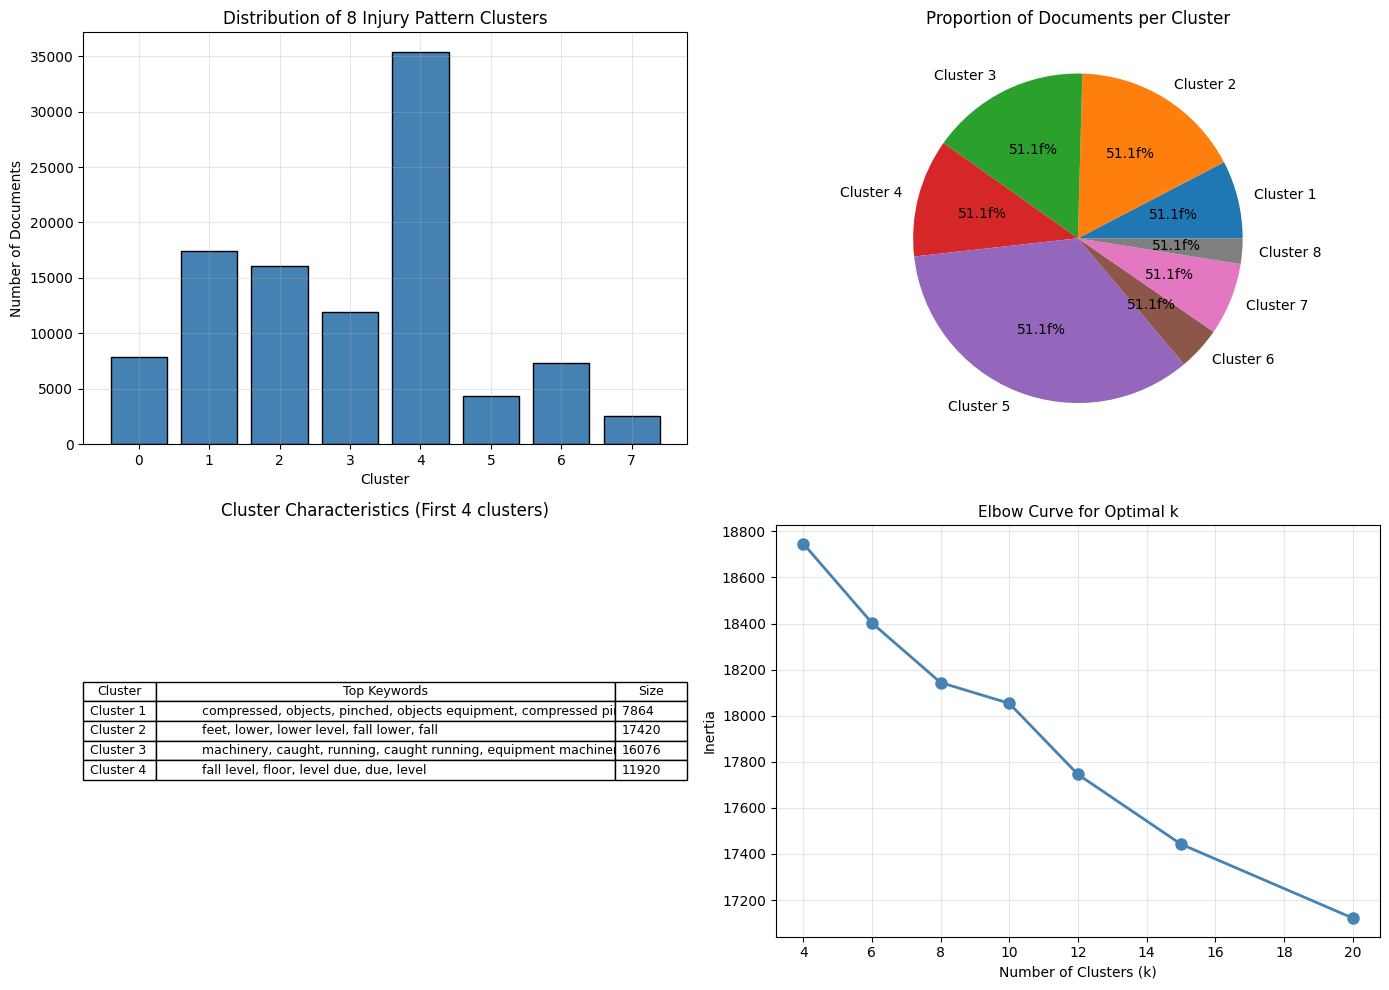

In [15]:
# visual comparison grid for k means

fig, axes=plt.subplots(2, 2, figsize=(14, 10))

# cluster distribution bar chart
axes[0,0].bar(range(k), counts, color='steelblue', edgecolor='black')
axes[0,0].set_xlabel('Cluster')
axes[0,0].set_ylabel('Number of Documents')
axes[0,0].set_title(f'Distribution of {k} Injury Pattern Clusters')
axes[0,0].grid(True, alpha=0.3)

# cluster size charts
axes[0,1].pie(counts, labels=[f'Cluster {i+1}' for i in range(k)], autopct='51.1f%%')
axes[0,1].set_title('Proportion of Documents per Cluster')

#top words table
cluster_data = []
for i in range(min(4, k)):
    top_words = get_top_words(centers_pp[i], feature_names, 5)
    cluster_data.append([f'Cluster {i+1}', ', '.join(top_words), counts[i]])
table =axes[1,0].table(cellText=cluster_data,
                         colLabels=['Cluster', 'Top Keywords', 'Size'],
                         cellLoc='left', loc='center', colWidths=[0.12, 0.76, 0.12])
table.auto_set_font_size(False)
table.set_fontsize(9)
axes[1,0].axis('off')
axes[1,0].set_title('Cluster Characteristics (First 4 clusters)')

# inertia comparison (placeholder)

k_values_test = [4, 6, 8, 10, 12, 15, 20]
inertias_test = []

elbow_sample_size = min(20000, tfidf_matrix.shape[0])
elbow_indices = np.random.choice(tfidf_matrix.shape[0], elbow_sample_size, replace=False)
tfidf_elbow_sample = tfidf_matrix[elbow_indices]

for k_val in k_values_test:
    mbk = MiniBatchKMeans(n_clusters=k_val, batch_size=2048, random_state=42, n_init=3)
    mbk.fit(tfidf_elbow_sample)
    inertias_test.append(mbk.inertia_)
    print(f"k={k_val}: inertia={mbk.inertia_:.0f}")

axes[1,1].plot(k_values_test, inertias_test, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[1,1].set_xlabel('Number of Clusters (k)', fontsize=10)
axes[1,1].set_ylabel('Inertia', fontsize=10)
axes[1,1].set_title('Elbow Curve for Optimal k', fontsize=11)
axes[1,1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [16]:
# with random initialization
kmeans_random=KMeans(n_clusters=k, init="random", random_state=42, n_init=10)
kmeans_random.fit(tfidf_sample)

labels_random=kmeans_random.predict(tfidf_matrix)
centers_random=kmeans_random.cluster_centers_

ari_score=adjusted_rand_score(labels_pp, labels_random)
print(f"Adjusted Rand Index between k-means++ and random: {ari_score:.3f}")
print("(Higher score = more stable clustering, >0.9 indicates very stable)")

print("\n" + "="*60)
print("TOP WORDS FROM RANDOM INIT (First 3 clusters)")
print("="*60)
for i in range(min(3, k)):
    top_words= get_top_words(centers_random[i], feature_names, 8)
    print(f"\nRandom Cluster {i+1}: {', '.join(top_words)}")

Adjusted Rand Index between k-means++ and random: 0.858
(Higher score = more stable clustering, >0.9 indicates very stable)

TOP WORDS FROM RANDOM INIT (First 3 clusters)

Random Cluster 1: feet, lower, lower level, fall lower, fall, level, fell, ladder

Random Cluster 2: machinery, caught, running, caught running, equipment machinery, running equipment, equipment, amputations

Random Cluster 3: heat, environmental, environmental heat, exposure environmental, heatenvironmental, systems heatenvironmental, body systems, systems


In [17]:
start_time=time.time()
minibatch=MiniBatchKMeans(n_clusters=k, batch_size=2048, random_state=42, n_init=3)
minibatch.fit(tfidf_sample)
mb_time=time.time() - start_time

labels_mb=minibatch.predict(tfidf_matrix)
centers_mb=minibatch.cluster_centers_

print(f"MiniBatchKMeans completed in {mb_time:.2f} seconds")
print(f"Cluster distribution:")
mb_counts =np.bincount(labels_mb)
for i, count in enumerate(mb_counts):
    print(f"  Cluster {i}: {count} documents ({count/len(labels_mb)*100:.1f}%)")

MiniBatchKMeans completed in 0.28 seconds
Cluster distribution:
  Cluster 0: 5643 documents (5.5%)
  Cluster 1: 29425 documents (28.6%)
  Cluster 2: 4297 documents (4.2%)
  Cluster 3: 15618 documents (15.2%)
  Cluster 4: 15929 documents (15.5%)
  Cluster 5: 7434 documents (7.2%)
  Cluster 6: 16448 documents (16.0%)
  Cluster 7: 8128 documents (7.9%)


 k=4: inertia=18698
 k=6: inertia=18409
 k=8: inertia=18225
 k=10: inertia=17890
 k=12: inertia=17764
 k=15: inertia=17587
 k=20: inertia=17225


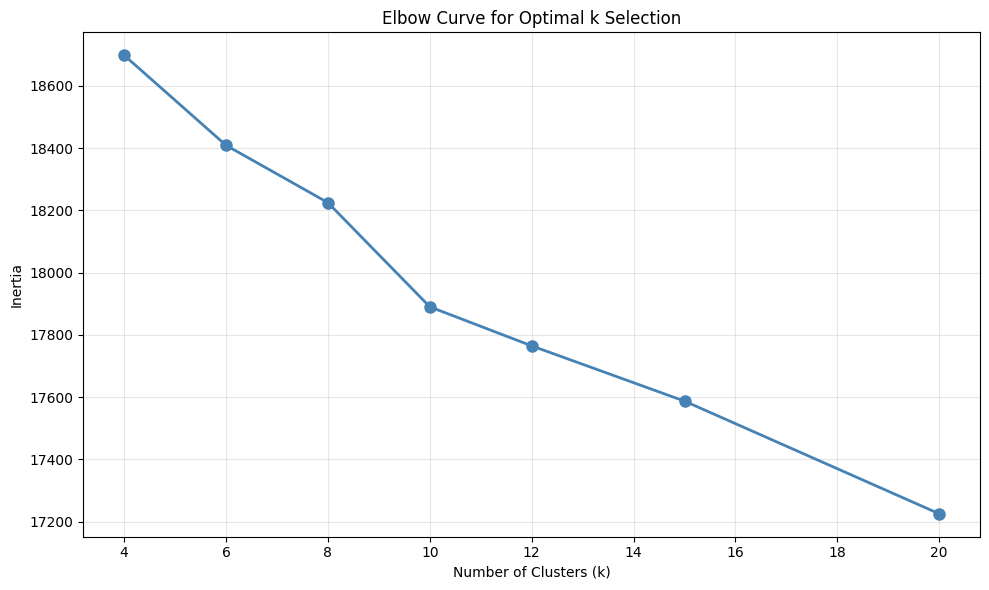


ELBOW CURVE ANALYSIS
k=4: inertia=18698
k=6: inertia=18409
k=8: inertia=18225
k=10: inertia=17890
k=12: inertia=17764
k=15: inertia=17587
k=20: inertia=17225


In [18]:
# elbow curve
k_values=[4,6,8,10,12,15,20]
inertias= []
elbow_sample_size=min(20000, tfidf_matrix.shape[0])
elbow_indices=np.random.choice(tfidf_matrix.shape[0], elbow_sample_size, replace=False)
tfidf_elbow_sample=tfidf_matrix[elbow_indices]

for k_val in k_values:
  mbk=MiniBatchKMeans(n_clusters=k_val, batch_size=2048, random_state=42, n_init=3)
  mbk.fit(tfidf_elbow_sample)
  inertias.append(mbk.inertia_)
  print(f" k={k_val}: inertia={mbk.inertia_:.0f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve for Optimal k Selection')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ELBOW CURVE ANALYSIS")
print("="*60)
for i, (k_val, inertia) in enumerate(zip(k_values, inertias)):
    print(f"k={k_val}: inertia={inertia:.0f}")

Original shape: (102922, 5000)
Reduced shape: (102922, 2)
Variance explained by PC1: 2.36%
Variance explained by PC2: 1.34%
Total variance explained: 3.69%


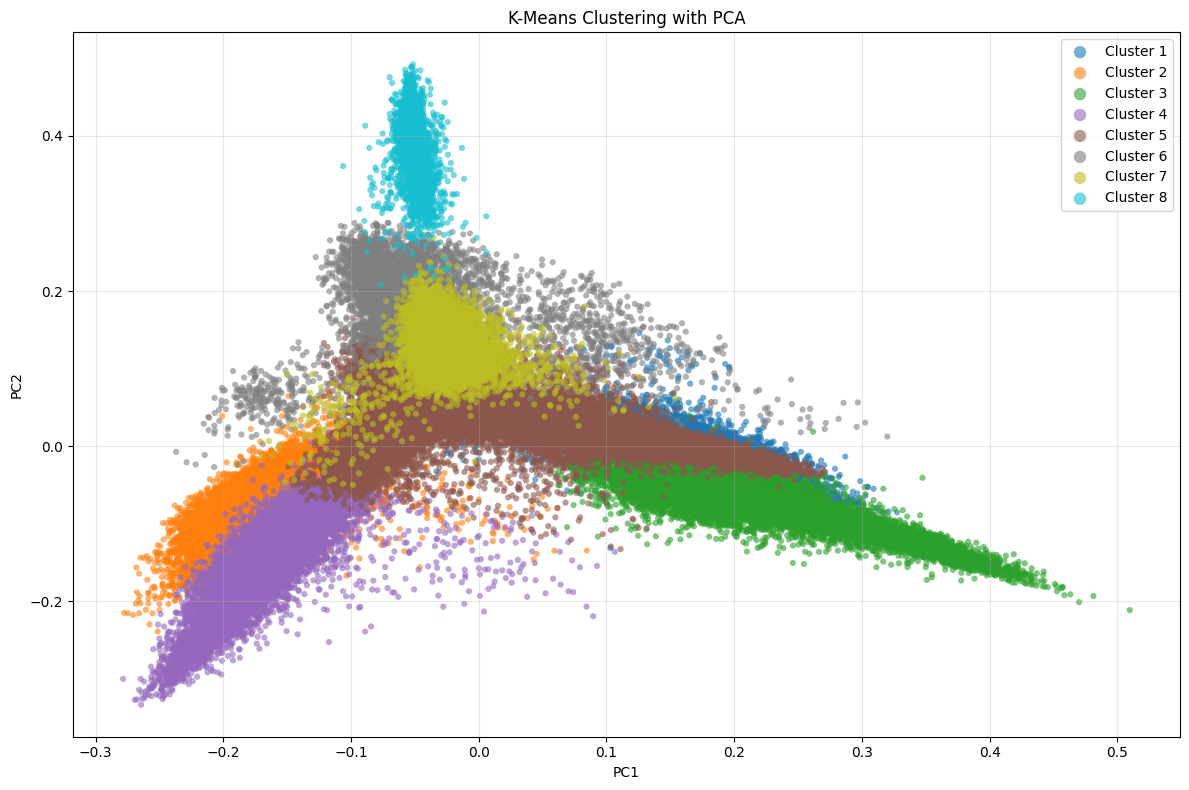

In [19]:
# 2D scatterplot of k means using PCA

pca=PCA(n_components=2, random_state=42)
tfidf_2d=pca.fit_transform(tfidf_matrix)

print(f"Original shape: {tfidf_matrix.shape}")
print(f"Reduced shape: {tfidf_2d.shape}")
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(12,8))

colors=plt.cm.tab10(np.linspace(0, 1, k))

for i in range(k):
  cluster_mask=labels_pp==i
  plt.scatter(tfidf_2d[cluster_mask, 0],
              tfidf_2d[cluster_mask, 1],
              c=[colors[i]],
              label=f'Cluster {i+1}',
              alpha=0.6,
              s=20,
              edgecolors='none')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering with PCA')
plt.legend(loc='best', markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# DBSCAN
structured_features =[
    'Primary NAICS',      # Industry code
    'Nature',             # Nature of injury code
    'Part of Body',       # Body part code
    'Event',              # Event type code
    'Source',             # Source code
    'Hospitalized',       # Binary
    'Amputation',         # Binary
    'Loss of Eye',        # Binary
    'FederalState'        # Binary
]

df_structured=df_clean[structured_features].copy()

label_encoders={}
for col in ['Primary NAICS', 'Nature', 'Part of Body', 'Event', 'Source']:
  le=LabelEncoder()

  df_structured[col]=df_structured[col].fillna('Unknown').astype(str)
  df_structured[col]=le.fit_transform(df_structured[col])
  label_encoders[col]=le

scaler = StandardScaler()
X_scaled=scaler.fit_transform(df_structured)

print(f"Shape for DBSCAN: {X_scaled.shape}")


Shape for DBSCAN: (102922, 9)


In [27]:
# subset DBSCAN with different eps

subset_size = 50000
np.random.seed(42)
subset_indices = np.random.choice(len(df_structured), subset_size, replace=False)
X_subset = X_scaled[subset_indices]

print(f"DBSCAN on subset of {subset_size} records (out of {len(X_scaled)} total)")

eps_values=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
min_samples=5

for eps in eps_values:
  dbscan=DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
  labels=dbscan.fit_predict(X_subset)

  n_clusters=len(set(labels)) - (1 if -1 in labels else 0)
  n_noise=list(labels).count(-1)

  print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points ({n_noise/len(labels)*100:.1f}%)")

DBSCAN on subset of 50000 records (out of 102922 total)
eps=0.5: 133 clusters, 2035 noise points (4.1%)
eps=1.0: 31 clusters, 406 noise points (0.8%)
eps=1.5: 12 clusters, 119 noise points (0.2%)
eps=2.0: 8 clusters, 51 noise points (0.1%)
eps=2.5: 3 clusters, 14 noise points (0.0%)
eps=3.0: 3 clusters, 9 noise points (0.0%)


In [28]:
# DBSCAN with visualization

best_eps=2.0 #Adjust

dbscan=DBSCAN(eps=best_eps, min_samples=5, metric='euclidean')
dbscan_labels=dbscan.fit_predict(X_subset)

n_clusters=len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise=list(dbscan_labels).count(-1)

print(f"DBSCAN with eps={best_eps}, min_samples=5")
print(f"Clusters found: {n_clusters}")
print(f"Noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f"Points in clusters: {len(dbscan_labels) - n_noise}")

unique, counts = np.unique(dbscan_labels, return_counts=True)
print("\nCluster sizes:")
for label, count in zip(unique, counts):
    if label == -1:
        print(f"  Noise (-1): {count} points")
    else:
        print(f"  Cluster {label}: {count} points")

DBSCAN with eps=2, min_samples=5
Clusters found: 8
Noise points: 51 (0.1%)
Points in clusters: 49949

Cluster sizes:
  Noise (-1): 51 points
  Cluster 0: 9260 points
  Cluster 1: 35734 points
  Cluster 2: 925 points
  Cluster 3: 3555 points
  Cluster 4: 258 points
  Cluster 5: 145 points
  Cluster 6: 66 points
  Cluster 7: 6 points


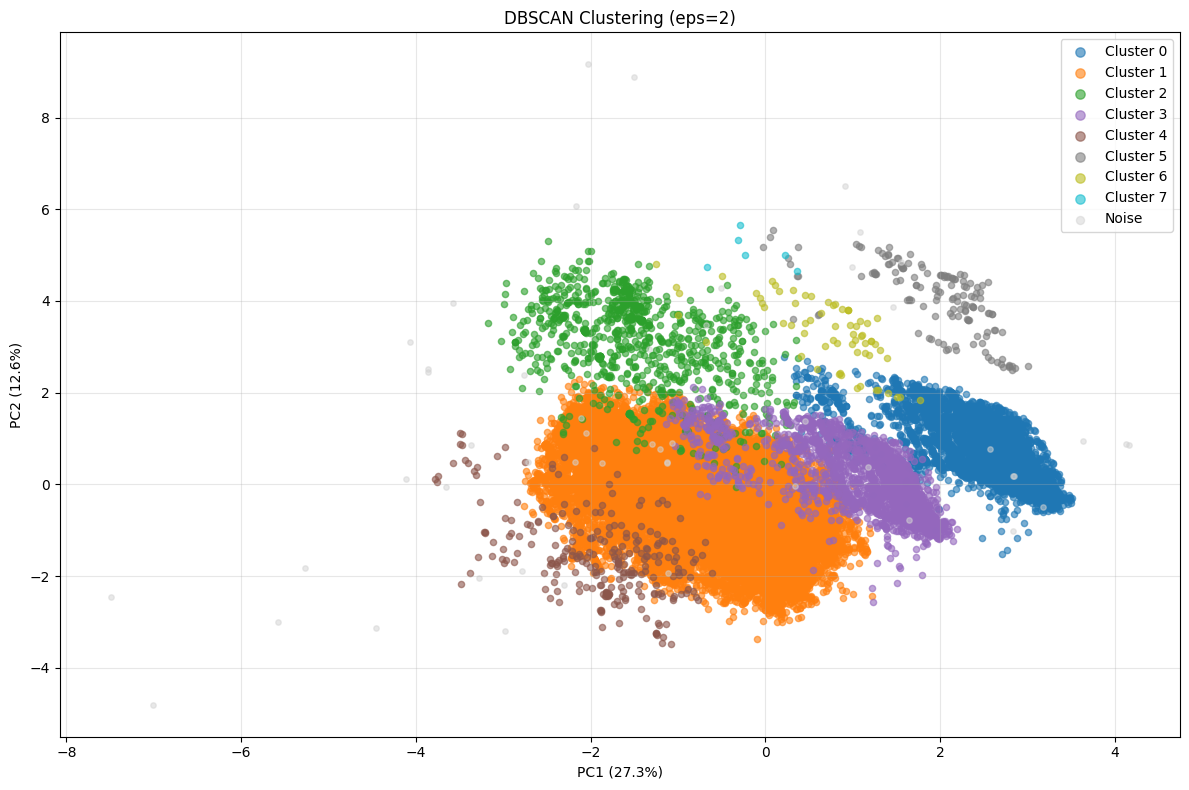

In [37]:
# DBSCAN with PCA

pca=PCA(n_components=2, random_state=42)
X_pca_subset=pca.fit_transform(X_subset)

plt.figure(figsize=(12, 8))

colors=plt.cm.tab10(np.linspace(0, 1, n_clusters))

for label in set(dbscan_labels):
  mask=dbscan_labels==label
  if label== -1:
    plt.scatter(X_pca_subset[mask, 0], X_pca_subset[mask, 1],
                c='lightgray', label='Noise', alpha=0.5, s=15)
  else:
    plt.scatter(X_pca_subset[mask, 0], X_pca_subset[mask, 1],
                   c=[colors[label % len(colors)]],
                   label=f'Cluster {label}', alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title(f'DBSCAN Clustering (eps={best_eps})')
plt.legend(loc='best', markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
for label in set(dbscan_labels):
    if label == -1:
        print(f"\n NOISE ({sum(dbscan_labels==label)} points) - Outliers")
    else:
        cluster_mask = dbscan_labels == label
        cluster_data = df_clean.iloc[subset_indices][cluster_mask]

        print(f"\n CLUSTER {label} ({cluster_mask.sum()} points)")
        print(f"  Top 3 Nature of Injury: {cluster_data['NatureTitle'].value_counts().head(3).to_dict()}")
        print(f"  Top 3 Event Types: {cluster_data['EventTitle'].value_counts().head(3).to_dict()}")
        print(f"  Top 3 Body Parts: {cluster_data['Part of Body Title'].value_counts().head(3).to_dict()}")
        print(f"  Hospitalization rate: {cluster_data['Hospitalized'].mean():.1%}")


 CLUSTER 0 (9260 points)
  Top 3 Nature of Injury: {'Amputations': 7878, ' Amputations, avulsions, enucleations  unspecified': 860, ' Amputations involving bone loss': 389}
  Top 3 Event Types: {'Caught in running equipment or machinery during regular operation': 1704, 'Compressed or pinched by shifting objects or equipment': 1400, 'Caught in running equipment or machinery during maintenance, cleaning ': 1280}
  Top 3 Body Parts: {'Fingertip(s)': 3839, 'Finger(s), fingernail(s), n.e.c.': 2456, 'Finger(s), fingernail(s), unspecified': 1348}
  Hospitalization rate: 0.0%

 CLUSTER 1 (35734 points)
  Top 3 Nature of Injury: {'Fractures': 13524, 'Soreness, pain, hurt-nonspecified injury': 3123, ' Fractures   ': 2421}
  Top 3 Event Types: {'Other fall to lower level, unspecified': 2872, 'Fall on same level due to slipping ': 1681, 'Other fall to lower level less than 6 feet': 1516}
  Top 3 Body Parts: {'Multiple body parts, n.e.c.': 2407, 'Leg(s), unspecified': 1949, 'BODY SYSTEMS': 1846}
 

In [31]:
table_data = []
for label in set(dbscan_labels):
    if label == -1:
        table_data.append({
            'Cluster': 'NOISE',
            'Size': sum(dbscan_labels == label),
            'Top Event': 'Outliers',
            'Top Nature': 'Outliers',
            'Top Body Part': 'Outliers',
            'Hospitalized %': 'N/A'
        })
    else:
        mask = dbscan_labels == label
        cluster_data = df_clean.iloc[subset_indices][mask]

        table_data.append({
            'Cluster': f'Cluster {label}',
            'Size': mask.sum(),
            'Top Event': cluster_data['EventTitle'].mode()[0][:45] if len(cluster_data['EventTitle'].mode()) > 0 else 'Unknown',
            'Top Nature': cluster_data['NatureTitle'].mode()[0][:35] if len(cluster_data['NatureTitle'].mode()) > 0 else 'Unknown',
            'Top Body Part': cluster_data['Part of Body Title'].mode()[0][:25] if len(cluster_data['Part of Body Title'].mode()) > 0 else 'Unknown',
            'Hospitalized %': f"{cluster_data['Hospitalized'].mean():.0%}"
        })

# Create and display table
df_cluster_table = pd.DataFrame(table_data)
print(df_cluster_table.to_string(index=False))

  Cluster  Size                                     Top Event              Top Nature             Top Body Part Hospitalized %
Cluster 0  9260 Caught in running equipment or machinery duri             Amputations              Fingertip(s)             0%
Cluster 1 35734        Other fall to lower level, unspecified               Fractures Multiple body parts, n.e.           100%
Cluster 2   925                Exposure to environmental heat               Fractures              BODY SYSTEMS           100%
Cluster 3  3555 Caught in running equipment or machinery duri             Amputations Finger(s), fingernail(s),           100%
Cluster 4   258 Inhalation of harmful substance-single episod               Fractures           Nonclassifiable           200%
Cluster 5   145 Compressed or pinched by shifting objects or              Amputations              Fingertip(s)             0%
Cluster 6    66 Compressed or pinched by shifting objects or              Amputations Finger(s), fingernail(s),

In [32]:
results = []
for label in set(dbscan_labels):
    if label != -1:
        mask = dbscan_labels == label
        d = df_clean.iloc[subset_indices][mask]
        results.append({
            'Cluster': label,
            'Size': len(d),
            'Event': d['EventTitle'].mode()[0][:35],
            'Nature': d['NatureTitle'].mode()[0][:30],
            'Body Part': d['Part of Body Title'].mode()[0][:20],
            'Hosp%': f"{d['Hospitalized'].mean():.0%}"
        })

pd.DataFrame(results).sort_values('Size', ascending=False)

,Cluster,Size,Event,Nature,Body Part,Hosp%
1,1,35734,"Other fall to lower level, unspecif",Fractures,"Multiple body parts,",100%
0,0,9260,Caught in running equipment or mach,Amputations,Fingertip(s),0%
3,3,3555,Caught in running equipment or mach,Amputations,"Finger(s), fingernai",100%
2,2,925,Exposure to environmental heat,Fractures,BODY SYSTEMS,100%
4,4,258,Inhalation of harmful substance-sin,Fractures,Nonclassifiable,200%
5,5,145,Compressed or pinched by shifting o,Amputations,Fingertip(s),0%
6,6,66,Compressed or pinched by shifting o,Amputations,"Finger(s), fingernai",100%
7,7,6,"Struck by dislodged flying object,","Avulsions, enucleations",Eye(s),100%


In [33]:
results = {
    'Total records': len(dbscan_labels),
    'Clusters found': len([l for l in set(dbscan_labels) if l != -1]),
    'Noise points': (dbscan_labels == -1).sum(),
    'Noise %': f"{(dbscan_labels == -1).sum()/len(dbscan_labels)*100:.1f}%",
    'Points in clusters': (dbscan_labels != -1).sum()
}

print(pd.DataFrame([results]).T)

                        0
Total records       50000
Clusters found          8
Noise points           51
Noise %              0.1%
Points in clusters  49949


In [34]:
# DBSCAN cluster counts
unique, counts = np.unique(dbscan_labels, return_counts=True)

df_counts = pd.DataFrame({
    'Cluster': unique,
    'Count': counts
})

df_counts['Cluster'] = df_counts['Cluster']
print(df_counts.to_string(index=False))

 Cluster  Count
      -1     51
       0   9260
       1  35734
       2    925
       3   3555
       4    258
       5    145
       6     66
       7      6


In [24]:
#BONUS random forest with cv
target = 'Hospitalized'
y = df_clean[target].fillna(0).values

exclude = ['ID', 'UPA', 'EventDate', 'Final Narrative', 'combined_text',
           'clean_text', 'text_length', 'Hospitalized', 'Amputation', 'Loss of Eye']
features = [c for c in df_clean.columns if c not in exclude]

X = df_clean[features].copy()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].fillna('Unknown').astype(str))
X = X.fillna(0)
X_scaled = StandardScaler().fit_transform(X)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
importances = []

for train_idx, val_idx in kf.split(X_scaled):
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_scaled[train_idx], y[train_idx])
    acc = rf.score(X_scaled[val_idx], y[val_idx])
    importances.append(rf.feature_importances_)
    print(f"Fold accuracy: {acc:.3f}")

avg_importances = np.mean(importances, axis=0)
imp_df = pd.DataFrame({'Feature': features, 'Importance': avg_importances}).sort_values('Importance', ascending=False)
print(imp_df.head(10))


Fold accuracy: 0.924
Fold accuracy: 0.922
Fold accuracy: 0.918
Fold accuracy: 0.921
Fold accuracy: 0.919
               Feature  Importance
10        Part of Body    0.195127
9          NatureTitle    0.191691
8               Nature    0.126892
11  Part of Body Title    0.063105
13          EventTitle    0.049301
12               Event    0.041218
5             Latitude    0.040238
6            Longitude    0.037350
0             Employer    0.036325
4                  Zip    0.036177


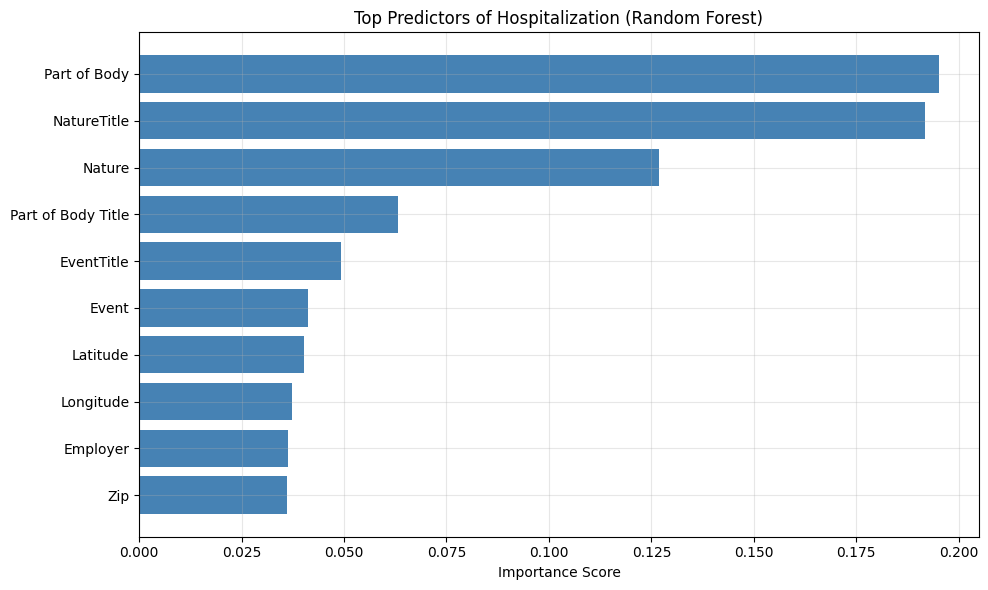

In [25]:
plt.figure(figsize=(10, 6))
plt.barh(imp_df.head(10)['Feature'], imp_df.head(10)['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top Predictors of Hospitalization (Random Forest)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
target2 = 'Amputation'
y2 = df_clean[target2].fillna(0).values

exclude = ['ID', 'UPA', 'EventDate', 'Final Narrative', 'combined_text',
           'clean_text', 'text_length', 'Hospitalized', 'Amputation', 'Loss of Eye']
features = [c for c in df_clean.columns if c not in exclude]

X2 = df_clean[features].copy()
for col in X2.select_dtypes(include=['object']).columns:
    X2[col] = LabelEncoder().fit_transform(X2[col].fillna('Unknown').astype(str))
X2 = X2.fillna(0)
X2_scaled = StandardScaler().fit_transform(X2)

kf2 = KFold(n_splits=5, shuffle=True, random_state=42)
importances2 = []

for train_idx, val_idx in kf2.split(X2_scaled):
    rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf2.fit(X2_scaled[train_idx], y2[train_idx])
    acc = rf2.score(X2_scaled[val_idx], y2[val_idx])
    importances2.append(rf2.feature_importances_)
    print(f"Fold accuracy: {acc:.3f}")

avg_importances2 = np.mean(importances2, axis=0)
imp_df2 = pd.DataFrame({'Feature': features, 'Importance': avg_importances2}).sort_values('Importance', ascending=False)
print(imp_df2.head(10))

Fold accuracy: 0.994
Fold accuracy: 0.994
Fold accuracy: 0.994
Fold accuracy: 0.993
Fold accuracy: 0.993
               Feature  Importance
9          NatureTitle    0.345065
10        Part of Body    0.229570
8               Nature    0.207173
11  Part of Body Title    0.070834
13          EventTitle    0.055846
12               Event    0.040873
15         SourceTitle    0.014260
14              Source    0.009749
7        Primary NAICS    0.004873
5             Latitude    0.003810


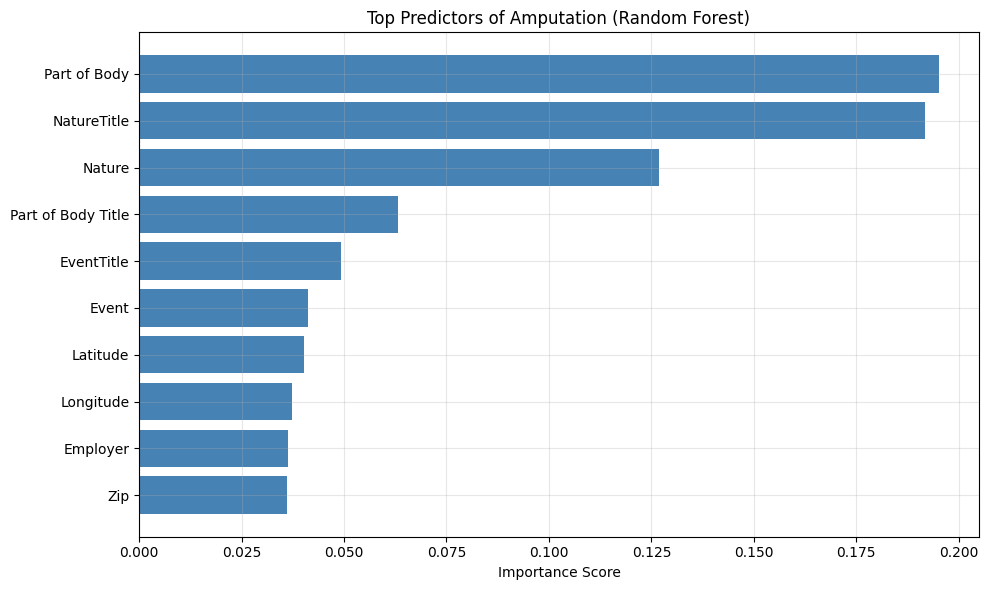

In [27]:
plt.figure(figsize=(10, 6))
plt.barh(imp_df.head(10)['Feature'], imp_df.head(10)['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top Predictors of Amputation (Random Forest)')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
!pip install treeple
from treeple import UnsupervisedRandomForest
urf = UnsupervisedRandomForest(
    n_estimators=100,
    criterion='twomeans',  # Maximizes variance between splits
    max_features='sqrt'
)
urf.fit(X_scaled)  # No y needed!

# Get proximity/affinity matrix (how similar samples are)
affinity = urf.apply(X_scaled)

NameError: name 'X_scaled' is not defined